# Анализ рынка общественного питания в Москве #

- Автор: Петрунин Богдан
- Дата: 04.07.2026

----

### Цели и задачи проекта

**Цель:** Провести исследовательский анализ данных рынка общественного питания в Москве на основе общедоступных данных (за 2022 год), чтобы помочь инвесторам определиться с типом и местом будущего заведения, а также помочь принять обоснованные решения.   

**Задачи:**     
1. Загрузить данные и познакомиться с ними.  
2. Провести предобработку данных.  
3. Провести исследовательский анализ данных:  
   - Анализ категорий заведений.  
   - Географическое распределение заведений.  
   - Соотношение сетевых и несетевых заведений.  
   - Анализ посадочных мест.  
   - Исследование рейтингов заведений.  
   - Поиск корреляции рейтинга с другими параметрами.  
   - Топ‑15 популярных сетей и их рейтинги.  
   - Анализ среднего чека по районам.  
4. Сформулировать выводы по проведённому анализу.

### Описание данных

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:  

- `name` — название заведения;  
- `address` — адрес заведения;  
- `district` — административный район, в котором находится заведение, например Центральный административный округ;  
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;  
- `hours` — информация о днях и часах работы;  
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);  
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):  
  * `0` — заведение не является сетевым;   
  * `1` — заведение является сетевым;   
- `seats` — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:  

- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;    
- `avg_bill` — хранит среднюю стоимость заказа в виде диапазона, например:    
  * «Средний счёт: 1000–1500 ₽»;  
  * «Цена чашки капучино: 130–220 ₽»;  
  * «Цена бокала пива: 400–600 ₽».  
  * и так далее;  
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Средний счёт»:  
  * Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.  
  * Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.  
  * Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.  
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца `avg_bill`, начинающихся с подстроки «Цена одной чашки капучино»:  
  * Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.  
  * Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.    
  * Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.  


### Содержимое проекта

1. Загрузка данных и знакомство с ними.  
2. Предобработка данных.  
3. Исследовательский анализ данных.  
4. Итоговые выводы.  
---

##  Загрузка данных и знакомство с ними

Сначала загрузим необходимые библиотеки для работы с данными: будем использовать библиотеку `pandas` для анализа данных, `matplotlib` и `seaborn` для визуализации, а библиотеку `phik` для построения матрицы корреляции.   
Загрузим датасеты `/datasets/rest_info.csv` и `/datasets/rest_price.csv` для знакомства с ними. Назовем их `info_df` и `price_df` соотвественно.

In [1]:
# Загружаем библитеку 
import pandas as pd

# Загружамем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции
!pip install phik
from phik import phik_matrix

     |████████████████████████████████| 677 kB 2.3 MB/s eta 0:00:01


In [2]:
# Загружаем датасеты
info_df = pd.read_csv('/datasets/rest_info.csv')
price_df = pd.read_csv('/datasets/rest_price.csv')

Познакомимся с датасетом `info_df`: выведем первые 5 строк методом head и общую информацию методом info.

In [3]:
# Выведем общую информацию датасета `info_df`
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [4]:
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


Датасет `info_df` имеет 9 столбцов и 8406 строк, в которых представлена информация о заведениях общепита в Москве.   
После первичного анализа можно сделать следующие выводы: 
1. Типы данных соответствуют своим значениям.Столбец `chain` содержит значения `0` и `1` - размерность этих данных также можно оптимизировать;    
2. Пропуски обнаружены только в столбцах `hours` и `seats`, однако, в остальных столбцах следует проверить наличие значений - индикаторов, которые могут говорить об отсутствии данных;  
1. Датасет имеет столбец `id`, который не указан в описании данных;  
2. Названия столбцов приведены к одному стилю;



Теперь познакомимся с данным датасета `price_df`

In [5]:
# Выведем общую информацию датасета `price_df`
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [6]:
# Выведем первые пять строк датасета `price_df`
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


Датасет `price_df` имеет 5 столбцов и 4058 строк, в которых представлена информация о среднем чеке в заведениях общественного питания.  

После первичного анализа можно сделать следующие выводы:  
1. Во всех столбцах, кроме `id` обнаружены пропуски;  
2. Типы данных соотвествуют ожидаемым;  
3. Столбец `id` также не был указан в описании данных;  
4. Названия столбцов приведены к единому стилю sakecase



---

### Промежуточный вывод

Первичное знакомство с данными показыает, что относительно хорошего качества -  названия столбцов приведены к единому стилю, тип данных соответсвует ожидаемому( но можно оптимизировать). Однако предстоит разобраться с пропусками в обоих датасетах, с написанием значений некоторых столбцов, а также решить, что делать со столбцом `id` который не был упомянут в описании данных.    

Судя по названию столбца `id`, он содержит уникальный идентификатор заведения, учтем это в дальнейшем анализе.

Теперь объединим оба датафрейма в один. Назовем его `df`. В качестве ключа используем столбец `id`.

In [7]:
# Объединим два датафрейма 
df = info_df.merge(price_df, on = 'id', how='outer')

In [8]:
# Выведем общую информацию 
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


In [9]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [10]:
# Запоминаем число строк после объединения, чтобы потом посчитать потери при предобработке
rows_before = len(df)

##  Предобработка данных


### Преобразование типов данных ###

In [11]:
# Оптимизируем целочисленный тип данных в столбце 'chain'
df['chain'] = pd.to_numeric(df['chain'],downcast = 'integer')

In [12]:
# Понижаем разрядность столбцов с числовыми данными
for column in ['rating','middle_avg_bill','middle_coffee_cup','seats']:
    df[column] = pd.to_numeric(df[column], downcast='float')

- Изучим пропущенные значения в данных: посчитаем их количество в каждом столбце датафрейме, изучим данные с пропущенными значениями и предположим гипотезы их появления. 

In [13]:
# Проверим количество пропусков в каждом столбце
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [14]:
# Посчитаем процент пропущеных значений в каждом столбце
round((df.isna().sum() / df.shape[0]) * 100, 2)

id                    0.00
name                  0.00
category              0.00
address               0.00
district              0.00
hours                 6.38
rating                0.00
chain                 0.00
seats                42.96
price                60.56
avg_bill             54.60
middle_avg_bill      62.54
middle_coffee_cup    93.64
dtype: float64

Итак, в данных обнаружено 6 столбцов с пропусками. Заполнять их искусственными значениями (модой, медианой или заглушками вроде `unknown`) не будем: это исказит данные и результаты дальнейшего анализа. Поэтому во всех столбцах оставляем пропуски как есть и учитываем их при анализе.

- Столбец `hours`. Пропуски в 6,38% носят не случайный характер, а скорее системный: они связаны с особенностями формата данных у заведений с гибким графиком и новых точек на карте Москвы. Удаление строк привело бы к потере информации о новых заведениях.
- Столбец `seats`. Пропуски в 42,96% могут говорить о технической ошибке при сборе данных или о том, что в маленьких заведениях количество мест не указывают. Оставляем пропуски как есть, чтобы не исказить информацию.
- Столбец `price`. Пропуски в 60,56% могут быть связаны как с технической ошибкой, так и с тем, что данные собирались из разных источников. Оставляем пропуски как есть, чтобы не исказить информацию при построении матрицы корреляции.
- Столбец `avg_bill`. Пропущено 54,6% значений: возможно, данные собирались из разных источников или заведения не указывают средний чек. Такие пропуски лучше оставить как есть.
- Столбцы `middle_avg_bill` и `middle_coffee_cup` имеют 62,54% и 93,64% пропусков соответственно. Эти показатели напрямую зависят от столбца `avg_bill`, поэтому пропуски здесь не ошибка, а особенность данных: если в `avg_bill` нет «Среднего счёта», то и в `middle_avg_bill` не должно быть значения. Заполнять их нельзя.

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float32
 7   chain              8406 non-null   int8   
 8   seats              4795 non-null   float32
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float32
 12  middle_coffee_cup  535 non-null    float32
dtypes: float32(4), int8(1), object(8)
memory usage: 730.6+ KB


In [21]:
# Проверим все пропуски 
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

- Проверим данные на явные и неявные дубликаты.Для оптимизации проверки нормализуем данные в текстовых столбцах.

In [22]:
#Поиск дубликатов по всем столбцам
duplicates = df[df.duplicated()]
print(duplicates)

#Количество дубликатов
print(f"Явных дубликатов: {df.duplicated().sum()}")

Empty DataFrame
Columns: [id, name, category, address, district, hours, rating, chain, seats, price, avg_bill, middle_avg_bill, middle_coffee_cup]
Index: []
Явных дубликатов: 0


**Явных дубликатов не обнаружено.**   
Далее посмотрим на неявные дубликаты.

In [23]:
# Нормализуем данные 
# Список столбцов для нормализации
columns_to_normalize = ['name','category','address','district','hours','price','avg_bill']

for i in columns_to_normalize:
    df[i] = (df[i]
               .str.lower()
               .str.replace('"', '')
               .str.replace("'", '')
               .str.replace(r'\s+', ' ', regex=True)
               .str.strip())

Посмотрим на уникальные значения в каждом строковом столбце

In [24]:
print(df['name'].nunique())
print(df['name'].unique())

5511
['wowфли' 'четыре комнаты' 'хазри' ... 'миславнес' 'самовар' 'kebab time']


In [25]:
print(df['category'].nunique())
print(df['category'].unique())

8
['кафе' 'ресторан' 'кофейня' 'пиццерия' 'бар,паб' 'быстрое питание'
 'булочная' 'столовая']


In [26]:
print(df['address'].nunique())
print(df['address'].unique())

5752
['москва, улица дыбенко, 7/1' 'москва, улица дыбенко, 36, корп. 1'
 'москва, клязьминская улица, 15' ...
 'москва, улица лобачевского, 52, корп. 1'
 'москва, болотниковская улица, 52, корп. 2'
 'москва, чонгарский бульвар, 26а, корп. 1']


In [27]:
print(df['district'].nunique())
print(df['district'].unique())

9
['северный административный округ'
 'северо-восточный административный округ'
 'северо-западный административный округ'
 'западный административный округ' 'центральный административный округ'
 'восточный административный округ' 'юго-восточный административный округ'
 'южный административный округ' 'юго-западный административный округ']


In [28]:
print(df['hours'].nunique())
print(list(df['hours'].unique()))

1307
['ежедневно, 10:00–22:00', 'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00', 'ежедневно, 09:00–22:00', 'ежедневно, 10:00–23:00', 'пн 15:00–04:00; вт-вс 15:00–05:00', 'пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00–22:00', 'ежедневно, 12:00–00:00', 'ежедневно, круглосуточно', 'ежедневно, 10:00–21:00', 'вт-сб 09:00–18:00', 'ежедневно, 08:00–22:00', 'ежедневно, 13:00–00:00', 'пн-пт 08:30–18:30; сб 10:00–20:00', 'ежедневно, 09:00–21:00', 'пн-пт 09:00–21:00', 'пн-чт 11:00–22:00; пт,сб 11:00–23:00; вс 11:00–22:00', 'пн-пт 08:00–22:00; сб,вс 10:00–22:00', 'ежедневно, 10:00–19:00', 'пн-пт 09:00–16:00', 'ежедневно, 08:00–21:00', 'ежедневно, 09:00–23:00', 'ежедневно, 08:00–23:00', nan, 'пн-пт 08:00–18:00', 'пн-пт 09:00–19:00', 'ежедневно, 11:00–00:00', 'ежедневно, 09:00–02:00', 'ежедневно, 12:00–23:00', 'ежедневно, 12:00–03:00', 'ежедневно, 16:00–06:00', 'пн-чт 12:30–00:00; пт,сб 12:30–02:00; вс 12:30–00:00', 'пн-сб 11:00–23:00; вс 12:00–23:00', 'пн-пт 08:00–19:00', 'пн-пт 11:00–22:00

In [29]:
print(df['price'].nunique())
print(df['price'].unique())

4
[nan 'выше среднего' 'средние' 'высокие' 'низкие']


In [30]:
print(df['avg_bill'].nunique())
print(df['avg_bill'].unique())

897
[nan 'средний счёт:1500–1600 ₽' 'средний счёт:от 1000 ₽'
 'цена чашки капучино:155–185 ₽' 'средний счёт:400–600 ₽'
 'средний счёт:199 ₽' 'средний счёт:200–300 ₽' 'средний счёт:от 500 ₽'
 'средний счёт:1000–1200 ₽' 'цена бокала пива:250–350 ₽'
 'средний счёт:330 ₽' 'средний счёт:1500 ₽' 'средний счёт:300–500 ₽'
 'средний счёт:140–350 ₽' 'средний счёт:350–500 ₽'
 'средний счёт:300–1500 ₽' 'средний счёт:от 240 ₽'
 'средний счёт:200–250 ₽' 'средний счёт:328 ₽' 'средний счёт:300 ₽'
 'средний счёт:от 345 ₽' 'средний счёт:60–400 ₽' 'средний счёт:900 ₽'
 'средний счёт:500–800 ₽' 'средний счёт:500–1000 ₽'
 'средний счёт:600–700 ₽' 'цена бокала пива:120–350 ₽'
 'средний счёт:1000–1500 ₽' 'средний счёт:1500–2000 ₽'
 'цена чашки капучино:150–190 ₽' 'средний счёт:2000–2500 ₽'
 'средний счёт:600 ₽' 'средний счёт:450 ₽' 'цена чашки капучино:120–170 ₽'
 'средний счёт:100–500 ₽' 'средний счёт:от 850 ₽'
 'цена чашки капучино:100–200 ₽' 'средний счёт:250–600 ₽'
 'средний счёт:2100 ₽' 'средний счёт:34

В столбцах `category`, `district` и `price` дубликатов не обнаружено. Все данные в нормальном виде.  
В столбцах `name`,`address`, `hours`,`avg_bill` очень много уникальных значений, поэтому вручную их посчитать невозможно.  

Попробуем обнаружить дубликаты по столбцам `name` и `address`


In [31]:
# Находим дубликаты по всем заведениям (включая сетевые)
duplicates_all = df[df[['name', 'address']].duplicated(keep=False)]

#print(f"Найдено дубликатов: {len(duplicates_all)}")
display(f"Найдено дубликатов: {len(duplicates_all)}")
#print(duplicates_all[['name', 'address', 'chain']])
duplicates_all[['name', 'address', 'chain']]

'Найдено дубликатов: 8'

,name,address,chain
189,кафе,"москва, парк ангарские пруды",0
215,кафе,"москва, парк ангарские пруды",0
1430,more poke,"москва, волоколамское шоссе, 11, стр. 2",0
1511,more poke,"москва, волоколамское шоссе, 11, стр. 2",1
2211,раковарня клешни и хвосты,"москва, проспект мира, 118",0
2420,раковарня клешни и хвосты,"москва, проспект мира, 118",1
3091,хлеб да выпечка,"москва, ярцевская улица, 19",1
3109,хлеб да выпечка,"москва, ярцевская улица, 19",0


Мы нашли 8 дубликатов, теперь нужно решить, что с ними делать. Сначала проверим, действиетльно ли эти строки являются дубликатами. Посмотрим на все столбцы у данной выборки.

In [33]:
# 1. Посмотрим на дубликаты сгруппированно
for (name, address), group in duplicates_all.groupby(['name', 'address']):
    if len(group) > 1:
        display(group[['id','name', 'address', 'chain', 'rating', 'seats', 'price']])

,id,name,address,chain,rating,seats,price
1430,62608690e9cc464fbcd980cfd552e334,more poke,"москва, волоколамское шоссе, 11, стр. 2",0,4.2,188.0,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,"москва, волоколамское шоссе, 11, стр. 2",1,4.2,188.0,NaN


,id,name,address,chain,rating,seats,price
189,072032ce16dc47bfbc63b672c75bd371,кафе,"москва, парк ангарские пруды",0,3.2,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,"москва, парк ангарские пруды",0,3.2,NaN,NaN


,id,name,address,chain,rating,seats,price
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,раковарня клешни и хвосты,"москва, проспект мира, 118",0,4.4,150.0,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"москва, проспект мира, 118",1,4.4,150.0,NaN


,id,name,address,chain,rating,seats,price
3091,3c2a73ea79a04be48858fab3685f2f37,хлеб да выпечка,"москва, ярцевская улица, 19",1,4.1,276.0,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,"москва, ярцевская улица, 19",0,4.1,276.0,NaN


Заметим, что все столбцы выборки совпадают, за исключенеим `id` и `chain`. Возможно, это произошло из-за того, что данные были собраны из разных источников, и при вненсении данных в базу были записаны оба варианта. Удалим дубликаты, оставив только первое вхождение.

In [34]:
# Удаляем дубликаты по name и address, оставляя первое вхождение
df.drop_duplicates(subset=['name', 'address'], keep = 'first', inplace=True)

print(f"После удаления дубликатов: {len(df)} строк")

После удаления дубликатов: 8402 строк


- Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [36]:
# Создаем столбец с логическими значениями
df['is_24_7'] = df['hours'] == 'ежедневно, круглосуточно'

# Проверяем результат
print(df[['hours', 'is_24_7']].head())
print("\nРаспределение:")
print(df['is_24_7'].value_counts())

                                               hours  is_24_7
0                             ежедневно, 10:00–22:00    False
1                             ежедневно, 10:00–22:00    False
2  пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...    False
3                             ежедневно, 09:00–22:00    False
4                             ежедневно, 10:00–22:00    False

Распределение:
False    7672
True      730
Name: is_24_7, dtype: int64


In [37]:
# Проверим сколько удалено строк датасета
a, b = rows_before, len(df)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 8406 
 Осталось строк в датасете после обработки 8402 
 Удалено строк в датасете после обработки 4 
 Процент потерь 0.05


---

### Промежуточный вывод


В результате объединения двух датасетов (`rest_info.csv` и `rest_price.csv`) по ключевому полю `id` был сформирован итоговый датафрейм размером 8 406 строк × 13 столбцов. Объединённый набор данных содержит полную информацию о заведениях общественного питания Москвы: название, адрес, категорию, район, режим работы, рейтинг, сети, количество посадочных мест, ценовую категорию, средний чек и производные числовые показатели (`middle_avg_bill`, `middle_coffee_cup`).

В ходе предобработки выполнена оптимизация типов данных с целью снижения занимаемой памяти и ускорения дальнейших вычислений:  
- Столбец `chain` приведён к целочисленному типу int8.
- Числовые столбцы `rating`, `seats`, `middle_avg_bill`, `middle_coffee_cup` понижены до float32.  
Все столбцы имеют корректные типы, соответствующие природе хранимых данных.

На этапе первичного анализа были выявлены пропуски в шести столбцах. Наибольшее количество пропусков зафиксировано в столбцах `middle_coffee_cup` (93,64%), `middle_avg_bill` (62,54%) и `price` (60,56%), тогда как в столбце `hours` пропуски составили лишь 6,38%. Для каждого столбца было принято решение: пропуски в `hours` (6,38%), `seats` (42,96%), `price` (60,56%), `avg_bill` (54,6%), `middle_avg_bill` (62,54%) и `middle_coffee_cup` (93,64%) оставлены без изменений, чтобы не исказить данные. При анализе они учитываются отдельно.

Явных полных дубликатов (совпадение по всем столбцам) не обнаружено. Однако выявлены 8 неявных дубликатов — 4 пары записей с одинаковыми значениями в столбцах `name` и `address`. При визуальной проверке установлено, что такие пары различаются только по `id` и `chain`, что указывает на дублирование из разных источников.
Принято решение удалить дубликаты с сохранением первого вхождения.

В соответствии с задачами исследования создан новый бинарный признак `is_24_7`, который принимает логические значения:
- True — заведение работает ежедневно и круглосуточно;
- False — в противоположном случае.  
Столбец создан на основе данных из поля `hours`.

Данные приведены к единому формату, пропуски изучены, дубликаты устранены (удалено 4 строки, 0,05% данных), добавлен новый значимый признак. Набор данных полностью готов к проведению исследовательского анализа: визуализации распределений, построению корреляционных матриц, группировкам и формированию выводов по всем заявленным в проекте задачам.



##  Исследовательский анализ данных


---

### Задача 1

Узнаем,какие категории заведений представлены в данных. Исследуем количество объектов общественного питания по каждой категории. 

                 Количество  Процент
кафе                   2376    28.28
ресторан               2042    24.30
кофейня                1413    16.82
бар,паб                 764     9.09
пиццерия                633     7.53
быстрое питание         603     7.18
столовая                315     3.75
булочная                256     3.05


<AxesSubplot:title={'center':'Количество заведений по каждой категории'}, xlabel='Вид заведения', ylabel='Количество заведений'>

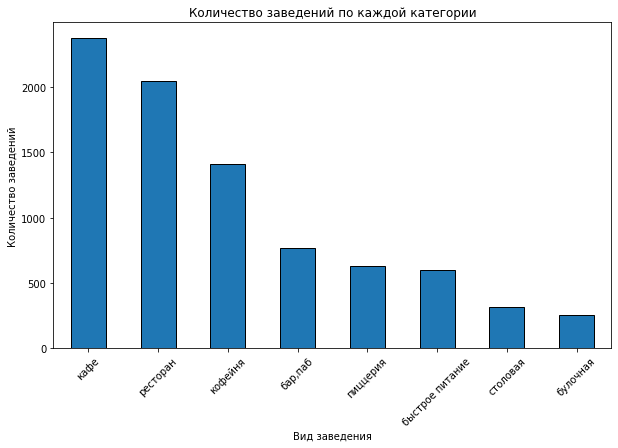

In [40]:
# Считаем количество заведений по категориям и процент от всех заведений
category_stats = pd.DataFrame({
    'Количество': df['category'].value_counts(),
    'Процент': round(df['category'].value_counts(normalize=True) * 100, 2)
})

print(category_stats)

# Создадим столбчатую диаграмму 
df['category'].value_counts().plot(kind = 'bar',
                                  rot = 45,
                                  xlabel = "Вид заведения",
                                  ylabel = "Количество заведений",
                                  figsize = (10, 6),
                                  edgecolor='black',
                                  title = "Количество заведений по каждой категории")

Рынок общественного питания Москвы характеризуется высокой концентрацией в трёх основных категориях (кафе, рестораны, кофейни), которые суммарно контролируют более двух третей всех заведений. Это указывает на предпочтение потребителями форматов с широким ассортиментом и возможностью длительного пребывания. Форматы быстрого обслуживания и узкоспециализированные заведения (булочные, столовые) занимают существенно меньшие доли, что может свидетельствовать о более высокой конкуренции в массовых сегментах и, напротив, о потенциальных нишах для развития в недостаточно представленных категориях.

---

### Задача 2

Узнаем, какие административные районы Москвы присутствуют в данных. Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.

                                         Количество  Доля
центральный административный округ             2242  0.27
северный административный округ                 898  0.11
южный административный округ                    892  0.11
северо-восточный административный округ         890  0.11
западный административный округ                 850  0.10
восточный административный округ                798  0.09
юго-восточный административный округ            714  0.08
юго-западный административный округ             709  0.08
северо-западный административный округ          409  0.05


<AxesSubplot:title={'center':'Распределение заведений по административным округам Москвы'}, ylabel='Местоположение'>

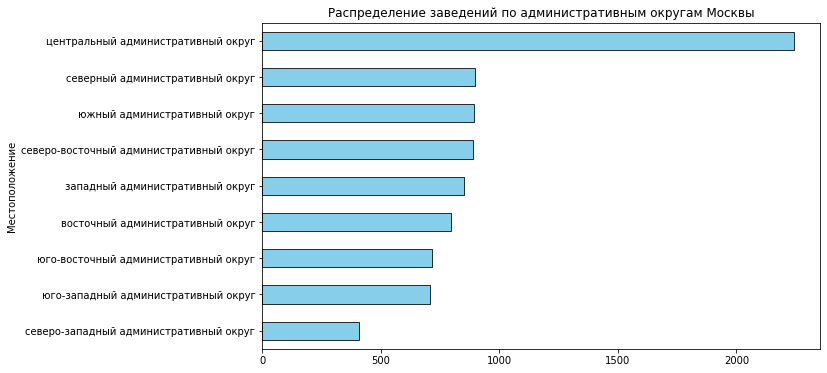

In [41]:
district_counts = pd.DataFrame({
    'Количество': df['district'].value_counts(),
    'Доля': round(df['district'].value_counts()/ df.shape[0],2)
})
print(district_counts)



# Построим линейчатую диаграмму
df['district'].value_counts().sort_values().plot(kind ='barh',
                                                ylabel = 'Количество заведений',
                                                xlabel = 'Местоположение',
                                                title='Распределение заведений по административным округам Москвы',
                                                edgecolor='black',
                                                figsize = (10,6),
                                                linewidth=0.8,
                                                color = 'skyblue')

Заметим, что Центральный административный округ существенно опережает остальные округа по количеству наблюдений - на его долю приходится 27 % от общего объёма данных (2242 случая), что почти в 2,5 раза выше показателей большинства других округов.  
Семь административных округов демонстрируют сопоставимые значения — в диапазоне 700–900. Такая картина говорит о равномерном распределении объектов.  

Изучим центральный округ отдельно.   

         Категория  Количество  Процент
0         ресторан         670    29.88
1             кафе         464    20.70
2          кофейня         428    19.09
3          бар,паб         364    16.24
4         пиццерия         113     5.04
5  быстрое питание          87     3.88
6         столовая          66     2.94
7         булочная          50     2.23


<AxesSubplot:title={'center':'Распределение категорий заведений в Центральном административном округе (ЦАО)'}, xlabel='Тип заведения', ylabel='Количество заведений'>

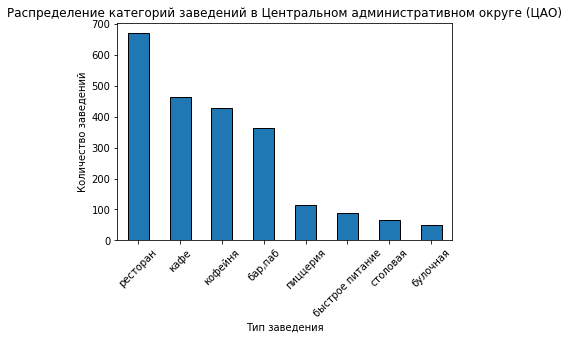

In [42]:
# Выделяем ЦАО 
cao_df = df[df['district'] == 'центральный административный округ']
 
# Считаем количество заведений по категориям
cao_category_stats = cao_df['category'].value_counts().reset_index()
cao_category_stats.columns = ['Категория', 'Количество']

# Находим проценты
cao_category_stats['Процент'] = round(cao_category_stats['Количество'] / cao_category_stats['Количество'].sum() * 100, 2)

print(cao_category_stats)

cao_df['category'].value_counts().plot(kind = 'bar',
                                      rot = 45,
                                      xlabel = 'Тип заведения',
                                      ylabel = 'Количество заведений',
                                      title='Распределение категорий заведений в Центральном административном округе (ЦАО)',
                                      edgecolor='black')


В Центральном округе лидируют рестораны (29,88 %), кафе (20,7 %) и кофейни (19,09 %), суммарно формируя более 69 % рынка. Это указывает на ориентацию спроса на формат полноценных заведений. Фаст фуд, столовые и булочные пользуются меньшим спросов. 

Также есть различия между ЦАО и всеми округами: в центре наибольшим спросом пользуются именно рестораны, а по в общем по округам - кафе. Это говорит о том, что локация является ключевым фактором, определяющим структуру спроса. В центральной части Москвы сконцентрированы платёжеспособные категории населения, которые готовы тратить больше времени и средств на полноценные обеды и ужины в ресторанах. Кроме того, в ЦАО выше доля вечернего и выходного трафика, что способствует развитию ресторанного формата.

---

### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения.Узнаем, каких заведений больше — сетевых или несетевых и какие категории заведений чаще являются сетевыми? 

         Тип  Количество  Процент
0  Несетевые        5199    61.88
1    Сетевые        3203    38.12


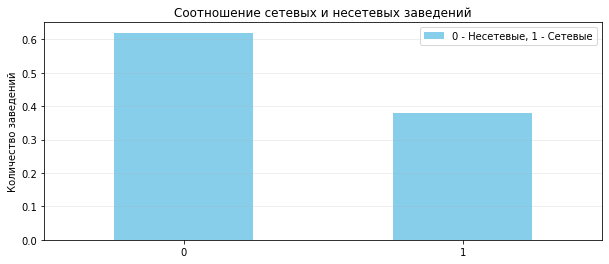

In [43]:
chain_stats = pd.DataFrame({
    'Тип': ['Несетевые','Сетевые'],
    'Количество': df['chain'].value_counts(),
    'Процент': round(df['chain'].value_counts(normalize=True) * 100, 2)
})
print(chain_stats)
ax = round(df['chain'].value_counts(normalize=True), 2).plot(kind ='bar',
                               rot = 0,
                               ylabel = 'Количество заведений',
                               title = 'Соотношение сетевых и несетевых заведений',
                               label ='0 - Несетевые, 1 - Сетевые',
                               legend = True,
                               color=['skyblue'],
                               figsize = (10,4)
                               
)
ax.grid(axis='y', alpha=0.3, linewidth=0.7) 

plt.show()

Несетевых заведений намного больше, чем сетевых (61% и 38% соответственно)

,Несетевые,Сетевые,Всего,Доля сетевых
category,,,,
булочная,99,157,256,0.61
пиццерия,303,330,633,0.52
кофейня,693,720,1413,0.51
быстрое питание,371,232,603,0.38
ресторан,1313,729,2042,0.36
кафе,1597,779,2376,0.33
столовая,227,88,315,0.28
"бар,паб",596,168,764,0.22


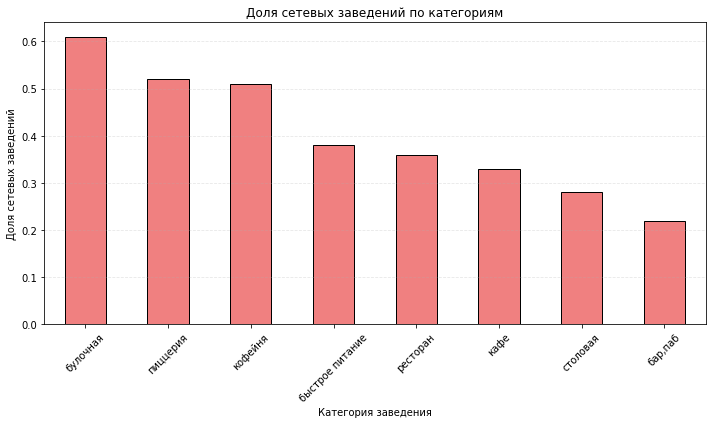

In [44]:
#  Считаем количество сетевых и несетевых по категориям
chain_by_category = df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
chain_by_category.columns = ['Несетевые', 'Сетевые']

# Добавляем процент сетевых
chain_by_category['Всего'] = chain_by_category['Несетевые'] + chain_by_category['Сетевые']

chain_by_category['Доля сетевых'] = round(chain_by_category['Сетевые'] / chain_by_category['Всего'], 2)

display(chain_by_category.sort_values('Доля сетевых',ascending=False))


(chain_by_category['Доля сетевых']).sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10, 6),
    color='lightcoral',
    edgecolor='black',
    title='Доля сетевых заведений по категориям',
    xlabel='Категория заведения',
    ylabel='Доля сетевых заведений',
    rot=45
)

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()




Анализ соотношения сетевых и несетевых заведений показал, что рынок общественного питания Москвы преимущественно представлен независимыми игроками: несетевые заведения составляют 61,88% (5 199 объектов), тогда как сетевые — 38,12% (3 203 объекта). Это свидетельствует о высоком уровне конкуренции и разнообразии предложения, где индивидуальные проекты занимают доминирующее положение.

При детальном рассмотрении в разрезе категорий выявлена значительная дифференциация уровня сетевизации. Наиболее сетевыми категориями являются:

- Булочные — 61% 
- Пиццерии — 52% 
- Кофейни — 51% 

Наименьшая доля сетевых заведений зафиксирована в категориях:
- Бар, паб — 22% 
- Столовая — 28% 
- Кафе — 33%   
Промежуточные позиции занимают быстрое питание (38%) и рестораны (36%), где сетевые проекты присутствуют, но не доминируют.

Таким образом, можно сделать вывод, что наиболее перспективными для масштабирования через сетевые форматы являются булочные, пиццерии и кофейни, тогда как в сегментах баров, столовых и кафе преобладают независимые проекты, что требует индивидуального подхода к каждой точке. Общий тренд указывает на зрелость рынка, где сосуществуют как крупные сетевые игроки, так и множество уникальных независимых заведений, что обеспечивает высокое разнообразие предложения для потребителей.

---

### Задача 4

Исследуем количество посадочных мест в заведениях. Проверим, встречаются ли в данных аномальные значения или выбросы. Приведем для каждой категории заведений наиболее типичное для него количество посадочных мест. 


count    4792.000000
mean      108.361435
std       122.841133
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64


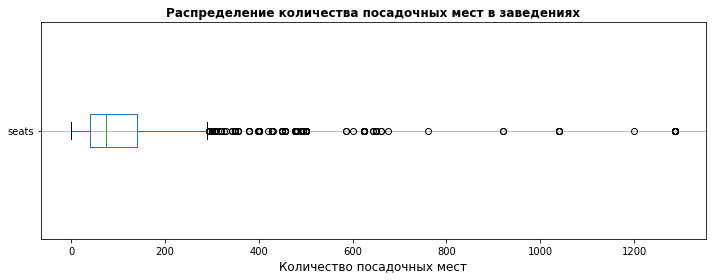

In [45]:
# Выведем показатели описательной статистики 
print(df['seats'].describe())

# Создадим диаграмму размаха
fig, ax = plt.subplots(figsize=(10, 4))
df.boxplot(column='seats', vert=False)
ax.set_title('Распределение количества посадочных мест в заведениях', fontweight='bold')
ax.set_xlabel('Количество посадочных мест', fontsize=12)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

Распределение количества посадочных мест имеет правостороннюю асимметрию — большинство заведений имеют относительно небольшое количество мест (40–140), но встречаются отдельные объекты с очень большим количеством мест, которые являются выбросами. Наиболее типичным значением для заведений общественного питания в Москве является медиана — 75 мест, так как она устойчива к влиянию выбросов и лучше отражает реальную ситуацию, чем среднее значение (108 мест), которое смещено в сторону аномально крупных заведений.
    
Предположения о природе выбросов:
- Крупные сетевые рестораны и флагманские точки — некоторые заведения сетей (например, "Му-Му", "Теремок", "Шоколадница") в центральных локациях имеют большие площади и вместимость, значительно превышающую среднюю.
- Предприятия общественного питания при крупных организациях — столовые в бизнес-центрах, в университетах, больницах, где количество мест может достигать сотен и даже тысяч.
- Специализированные заведения с большой площадью — концертные залы с ресторанным обслуживанием, выставочные центры, банкетные залы.
- Столовые в местах массового скопления людей — вокзалы, аэропорты, крупные торговые центры.
- Возможные технические ошибки — не исключено, что часть аномально высоких значений может быть связана с ошибками при сборе данных (например, указано общее количество мест по сети, а не по одному заведению).



Для более точного анализа по каждой категории заведений необходимо дополнительно изучить распределение в разрезе типов заведений, так как количество мест сильно зависит от формата (например, булочные и кофейни ожидаемо имеют меньше мест, чем рестораны и столовые).

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",467.0,124.477516,145.162277,0.0,48.0,82.0,148.5,1288.0
булочная,148.0,89.385132,97.685844,0.0,25.0,50.0,120.0,625.0
быстрое питание,349.0,98.891121,106.611740,0.0,28.0,65.0,140.0,1040.0
кафе,1217.0,97.365654,117.922462,0.0,35.0,60.0,120.0,1288.0
кофейня,751.0,111.199730,127.837776,0.0,40.0,80.0,144.0,1288.0
пиццерия,427.0,94.496490,112.282707,0.0,30.0,55.0,120.0,1288.0
ресторан,1269.0,121.892044,123.792213,0.0,48.0,86.0,150.0,1288.0
столовая,164.0,99.750000,122.951454,0.0,40.0,75.5,117.0,1200.0


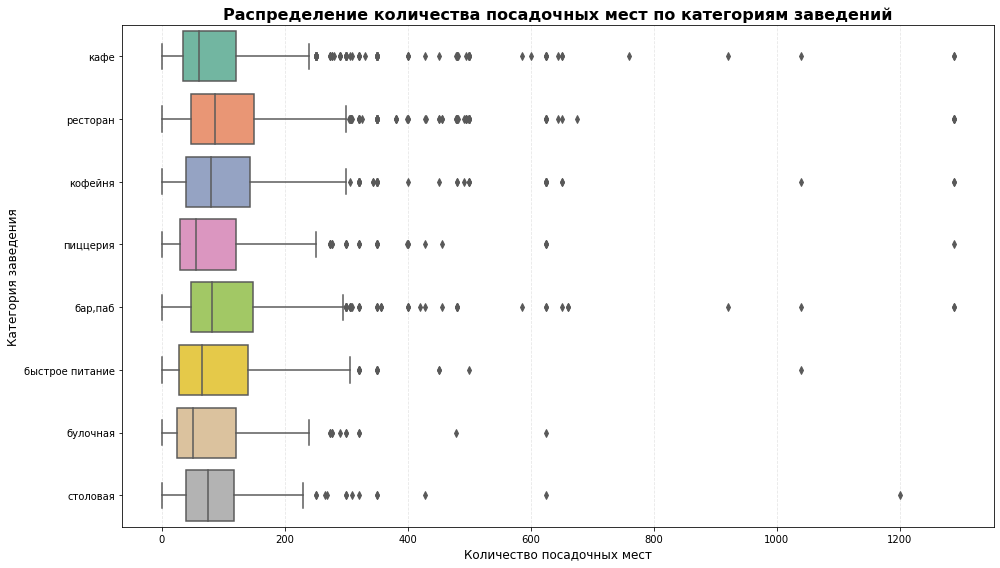

In [46]:
# Выведем показатели для каждой категории
seats_stats = df.groupby('category')['seats'].describe()
display(seats_stats)

# Создадим диаграмму размаха для каждой категории
fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(data=df, x='seats', y='category', palette='Set2', ax=ax)

# Оформление графика
ax.set_title('Распределение количества посадочных мест по категориям заведений', fontsize=16, fontweight='bold')
ax.set_xlabel('Количество посадочных мест', fontsize=12)
ax.set_ylabel('Категория заведения', fontsize=12)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

ТИПИЧНОЕ КОЛИЧЕСТВО МЕСТ ПО КАТЕГОРИЯМ


,Медиана,Среднее
category,,
ресторан,86.0,121.892044
"бар,паб",82.0,124.477516
кофейня,80.0,111.199730
столовая,75.5,99.750000
быстрое питание,65.0,98.891121
кафе,60.0,97.365654
пиццерия,55.0,94.496490
булочная,50.0,89.385132


<Figure size 720x432 with 0 Axes>

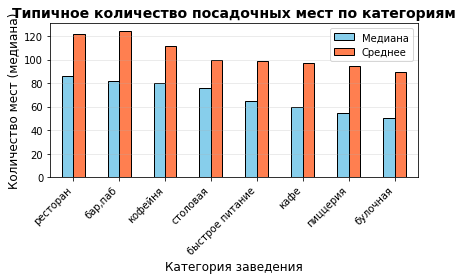


Вывод:
  • Самые вместительные: Рестораны — 86 мест
  • Самые компактные: Булочные — 50 мест
  • Типичная кофейня: 80 мест
  • Типичное кафе: 60 мест


In [47]:
# Сравнение медианы и среднего
typical_seats = df.groupby('category')['seats'].agg(['median', 'mean'])
typical_seats.columns = ['Медиана', 'Среднее']
typical_seats = typical_seats.sort_values('Медиана', ascending=False)

print("ТИПИЧНОЕ КОЛИЧЕСТВО МЕСТ ПО КАТЕГОРИЯМ")
display(typical_seats)

# Строим диаграмму
plt.figure(figsize=(10, 6))
typical_seats.plot(kind='bar', color=['skyblue', 'coral'], edgecolor='black')
plt.title('Типичное количество посадочных мест по категориям', fontsize=14, fontweight='bold')
plt.xlabel('Категория заведения', fontsize=12)
plt.ylabel('Количество мест (медиана)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Краткий вывод
print("\nВывод:")
print(f"  • Самые вместительные: Рестораны — {typical_seats.loc['ресторан', 'Медиана']:.0f} мест")
print(f"  • Самые компактные: Булочные — {typical_seats.loc['булочная', 'Медиана']:.0f} мест")
print(f"  • Типичная кофейня: {typical_seats.loc['кофейня', 'Медиана']:.0f} мест")
print(f"  • Типичное кафе: {typical_seats.loc['кафе', 'Медиана']:.0f} мест")

На основе медианных значений наиболее типичное (характерное) количество посадочных мест для каждой категории заведений составляет:
- Ресторан — 86 мест
- Бар, паб — 82 места
- Кофейня — 80 мест
- Столовая — 75,5 места
- Быстрое питание — 65 мест
- Кафе — 60 мест
- Пиццерия — 55 мест
- Булочная — 50 мест  
Таким образом, самой вместительной категорией являются рестораны, самой компактной — булочные. При этом медианные значения во всех случаях ниже средних арифметических, что указывает на наличие в каждой категории отдельных заведений с аномально большим числом мест, смещающих среднее вверх.

Анализ количества посадочных мест в разрезе категорий заведений показывает, что наиболее вместительными являются рестораны (медиана 86 мест, среднее 122 места), бары и пабы (медиана 82 места, среднее 124 места) и кофейни (медиана 80 мест, среднее 111 мест). Эти форматы ориентированы на длительное пребывание гостей и требуют большего пространства.

Среднюю вместимость демонстрируют столовые (медиана 75,5 мест, среднее 100 мест) и заведения быстрого питания (медиана 65 мест, среднее 99 мест). Наименьшее количество мест традиционно у булочных (медиана 50 мест, среднее 89 мест) и пиццерий (медиана 55 мест, среднее 94 места), что соответствует их формату, ориентированному на быстрый оборот посетителей.

**Важное наблюдение:** практически во всех категориях среднее значение значительно превышает медиану (например, у баров среднее 124 против медианы 82, у столовых — 100 против 75,5). Это указывает на наличие выбросов в сторону больших значений — крупных заведений с аномально высоким количеством мест, которые "тянут" среднее вверх. Медиана в данном случае является более репрезентативным показателем, так как она устойчива к выбросам и лучше отражает типичное количество мест для каждой категории.

Максимальное количество мест (до 1 288) встречается в ресторанах, барах, кафе и кофейнях — это, вероятно, крупные сетевые проекты, банкетные залы или столовые при крупных организациях. Минимальное значение 0 мест во всех категориях может быть связано с техническими ошибками в данных или заведениями, работающими исключительно на вынос.

---

### Задача 5

Исследуем рейтинг заведений. Визуализируем распределение средних рейтингов по категориям заведений. Узнаем, сильно ли различаются усреднённые рейтинги для разных типов общепита.

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
"бар,паб",764.0,4.387697,0.380392,1.1,4.3,4.4,4.6,5.0
булочная,256.0,4.268360,0.386303,1.3,4.2,4.3,4.4,5.0
быстрое питание,603.0,4.050249,0.560949,1.1,3.9,4.2,4.3,5.0
кафе,2376.0,4.124284,0.566001,1.0,4.0,4.2,4.4,5.0
кофейня,1413.0,4.277282,0.372250,1.4,4.1,4.3,4.4,5.0
пиццерия,633.0,4.301264,0.336162,1.0,4.2,4.3,4.4,5.0
ресторан,2042.0,4.290401,0.413143,1.0,4.2,4.3,4.5,5.0
столовая,315.0,4.211429,0.454205,1.0,4.1,4.3,4.4,5.0


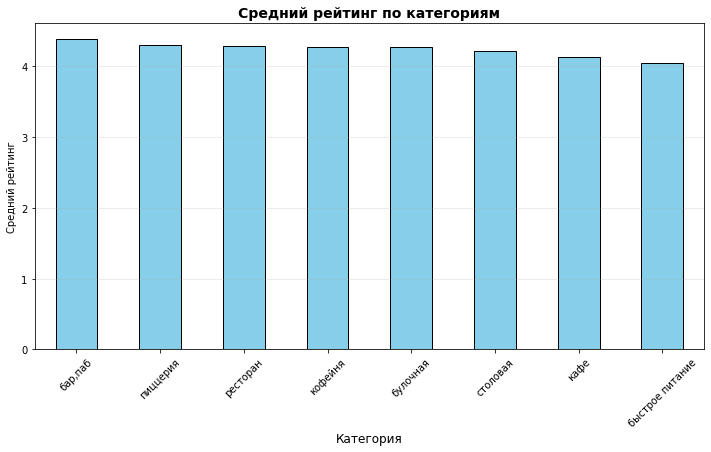

In [48]:
# Считаем средние рейтинги по категориям
rating_category = df.groupby('category')['rating'].describe()

display(rating_category)

#  Строим график
rating_category = df.groupby('category')['rating'].mean().sort_values(ascending=False).plot(kind='bar', color='skyblue', edgecolor='black', figsize=(12, 6))
plt.title('Средний рейтинг по категориям', fontsize=14, fontweight='bold')
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

Анализ средних рейтингов показывает, что все категории заведений в Москве имеют высокие и примерно одинаковые оценки — в диапазоне от 4.05 до 4.38 из 5. Разница между лучшей и худшей категорией составляет всего 0.33 балла, что говорит о незначительных различиях.

Несмотря на то, что все категории имеют оценки выше 4 баллов, различия между ними статистически значимы. Наиболее высокие оценки получают бары, пиццерии и рестораны, что свидетельствует о высоком качестве обслуживания и удовлетворённости клиентов в этих сегментах. Наименьшие оценки у быстрого питания и кафе, что может указывать на необходимость повышения качества сервиса или более жёсткие ожидания потребителей.

Для инвестора это означает, что при открытии заведения важно учитывать не только средний рейтинг категории, но и его вариативность — в категориях с большим разбросом (бары, булочные) есть возможность выделиться на фоне конкурентов, предложив более высокий уровень сервиса. В то же время в стабильных категориях (кафе, кофейни) конкурентное преимущество сложнее достичь за счёт одного лишь качества обслуживания — потребуется уникальная концепция или ценовая стратегия.

---

### Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений. Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберем самую сильную связь и проверим её.

interval columns not set, guessing: ['seats', 'rating']
Полная матрица корреляции(Phi_K)
          category  district  chain  seats  price  is_24_7  rating
category     1.000     0.175  0.266  0.049  0.567    0.245   0.199
district     0.175     1.000  0.064  0.352  0.203    0.076   0.189
chain        0.266     0.064  1.000  0.057  0.218    0.043   0.119
seats        0.049     0.352  0.057  1.000  0.065    0.043   0.000
price        0.567     0.203  0.218  0.065  1.000    0.084   0.262
is_24_7      0.245     0.076  0.043  0.043  0.084    1.000   0.161
rating       0.199     0.189  0.119  0.000  0.262    0.161   1.000


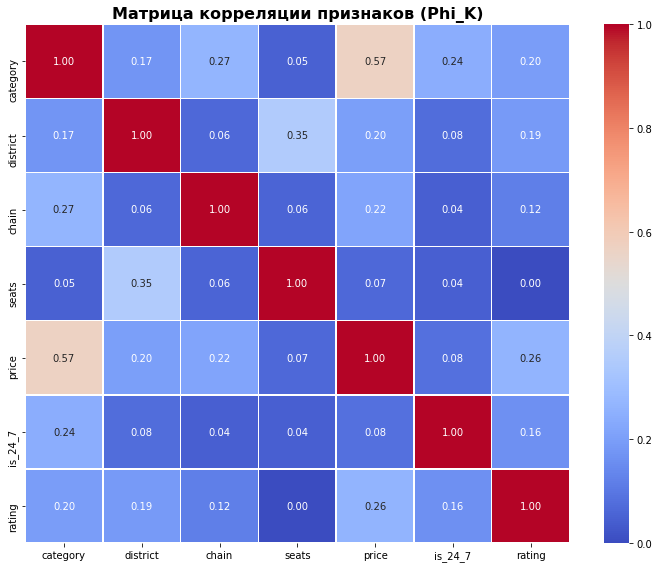

Корреляция рейтинга с другими признаками


,rating
price,0.262
category,0.199
district,0.189
is_24_7,0.161
chain,0.119
seats,0.000


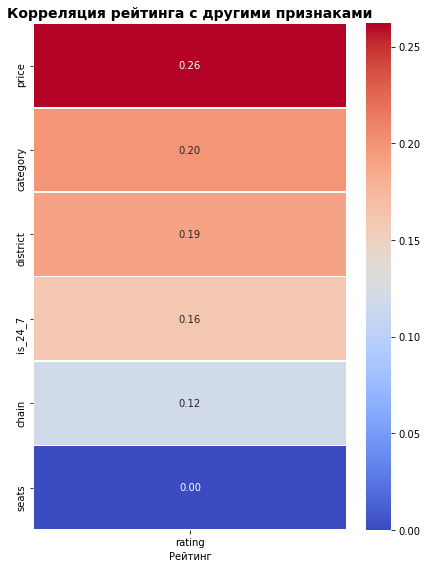

In [50]:
# Подготовка данных для корреляционного анализа
df_corr = df.copy()

# Преобразуем категориальные признаки в тип 'category'
df_corr['category'] = df_corr['category'].astype('category')
df_corr['district'] = df_corr['district'].astype('category')
df_corr['price'] = df_corr['price'].astype('category')
df_corr['is_24_7'] = df_corr['is_24_7'].astype('category')
df_corr['chain'] = df_corr['chain'].astype('category')


# Выбираем столбцы для анализа
cols = ['category', 'district', 'chain', 'seats', 'price', 'is_24_7', 'rating']
correlation_matrix = df_corr[cols].phik_matrix()

# Выводим полную матрицу корреляции
print("Полная матрица корреляции(Phi_K)")
print(correlation_matrix.round(3))

# Визуализация полной матрицы корреляции
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar=True)
plt.title('Матрица корреляции признаков (Phi_K)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Корреляция рейтинга с другими признаками (табличный вид)
print("Корреляция рейтинга с другими признаками")
rating_corr = correlation_matrix[['rating']].drop('rating').sort_values(by='rating', ascending=False)
display(rating_corr.round(3))

# Тепловая карта корреляции рейтинга с другими признаками
plt.figure(figsize=(6, 8))
sns.heatmap(rating_corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar=True)
plt.title('Корреляция рейтинга с другими признаками', fontsize=14, fontweight='bold')
plt.xlabel('Рейтинг')
plt.tight_layout()
plt.show()

Все рассмотренные признаки показывают слабую или очень слабую корреляцию с рейтингом. Наибольшее влияние оказывает ценовая категория: вероятно,заведения с более высокими ценами склонны получать более высокие оценки. Однако коэффициенты корреляции ниже 0,3 свидетельствуют о том, что рейтинг заведения формируется под влиянием других факторов, не включённых в данный анализ: качество обслуживания, вкус и качество еды, атмосфера, уникальность концепции, уровень сервиса, маркетинговая активность и работа с отзывами.

In [52]:
# Вывод статистики по ценовым категориям
print("Статистика рейтинга по ценовым категориям")
price_rating_stats = df.groupby('price')['rating'].agg(['count', 'mean', 'median', 'std']).round(3)
display(price_rating_stats)

print("\nСредний рейтинг по ценовым категориям (по убыванию)")
display(df.groupby('price')['rating'].mean().sort_values(ascending=False).round(3))

Статистика рейтинга по ценовым категориям


,count,mean,median,std
price,,,,
высокие,478,4.437,4.4,0.314
выше среднего,564,4.386,4.4,0.224
низкие,156,4.173,4.2,0.373
средние,2117,4.298,4.3,0.296



Средний рейтинг по ценовым категориям (по убыванию)


price
высокие          4.437
выше среднего    4.386
средние          4.298
низкие           4.173
Name: rating, dtype: float32

Средний рейтинг последовательно растёт от категории «низкие» (4,17) до «высокие» (4,44). Разница между крайними категориями составляет 0,26 балла, что в контексте 5-балльной шкалы является заметным расхождением.

Во всех категориях медиана близка к среднему значению, что говорит о симметричном распределении оценок. Наиболее стабильные оценки (наименьшее стандартное отклонение) — у категории «выше среднего» (0,224), что указывает на предсказуемое качество в этом сегменте.
Наибольший разброс оценок — у категории «низкие» (0,373), что говорит о высокой вариативности качества в бюджетном сегменте: здесь встречаются как очень хорошие, так и крайне низкие оценки.

Самая многочисленная категория — «средние» (2 117 заведений), что отражает основную массу рынка общественного питания.

---

### Задача 7

Сгруппируем данные по названиям заведений и найдем топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга.Узнаем, к какой категории заведений они относятся.

In [54]:
# Получаем топ-15 самых частых названий сетевых заведений
top_chain = df[df['chain'] == 1]['name'].value_counts().head(15)

# Создаём DataFrame с топ-15 названиями
top_names = pd.DataFrame(top_chain.index, columns=['name'])

# Объединяем с датафреймом, чтобы получить все категории для топ-названий
top_data = df.merge(top_names, on='name', how='inner')

# Группируем по имени и категории (исправленная часть)
result = top_data.groupby(['name', 'category']).agg({
    'name': 'count',  # количество заведений в этой категории сети
    'rating': 'mean'  # средний рейтинг для этой категории сети
}).rename(columns={
    'name': 'Количество',
    'rating': 'Средний рейтинг'
}).reset_index()

# Переименовываем столбцы для читаемости
result.columns = ['Название сети', 'Категория', 'Количество', 'Средний рейтинг']

# Сортируем по количеству заведений 
result = result.sort_values('Количество', ascending=False)

# Оставляем топ-15 по количеству заведений
result_top15 = result.head(15)
result_top15

,Название сети,Категория,Количество,Средний рейтинг
31,шоколадница,кофейня,119,4.178151
10,доминос пицца,пиццерия,78,4.171795
9,додо пицца,пиццерия,74,4.286487
3,one price coffee,кофейня,72,4.069445
32,яндекс лавка,ресторан,69,3.872464
2,cofix,кофейня,65,4.075385
5,prime,ресторан,49,4.114285
11,кофепорт,кофейня,42,4.147619
12,кулинарная лавка братьев караваевых,кафе,39,4.394872
21,теремок,ресторан,36,4.105556


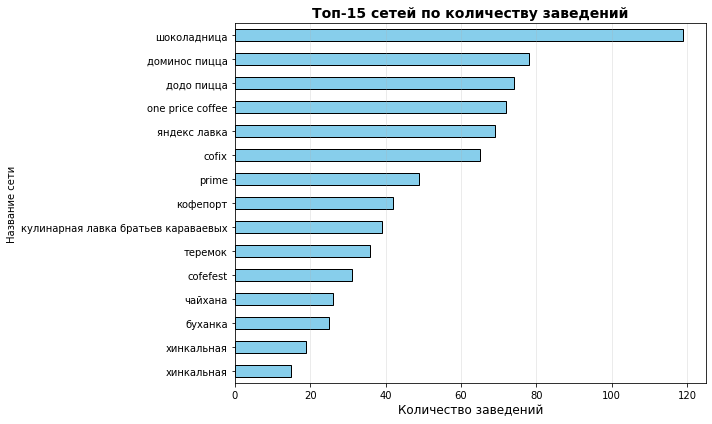

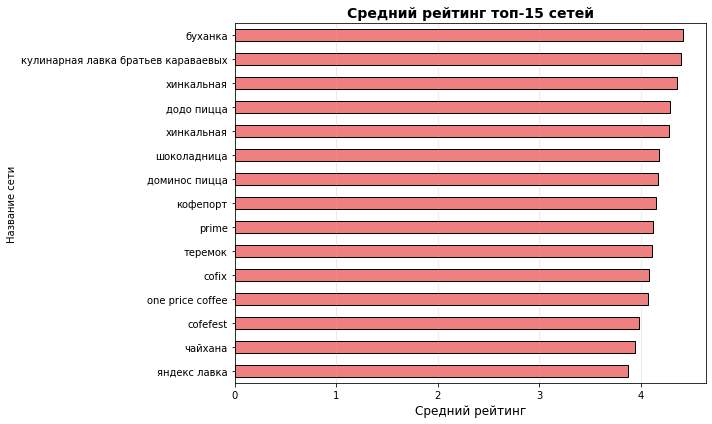

In [56]:
# 1. Диаграмма по количеству заведений
plt.figure(figsize=(10, 6))

# Устанавливаем 'Название сети' как индекс
plot_data = result_top15.set_index('Название сети')
plot_data['Количество'].sort_values().plot(kind='barh', color='skyblue', edgecolor='black')

plt.title('Топ-15 сетей по количеству заведений', fontsize=14, fontweight='bold')
plt.xlabel('Количество заведений', fontsize=12)
plt.ylabel('Название сети')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Диаграмма по среднему рейтингу
plt.figure(figsize=(10, 6))

# Устанавливаем 'Название сети' как индекс
plot_data = result_top15.set_index('Название сети')
plot_data['Средний рейтинг'].sort_values().plot(kind='barh', color='lightcoral', edgecolor='black')

plt.title('Средний рейтинг топ-15 сетей', fontsize=14, fontweight='bold')
plt.xlabel('Средний рейтинг', fontsize=12)
plt.ylabel('Название сети')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Кофейни доминируют в топе — 6 из 15 сетей относятся к кофейному сегменту, что подтверждает высокую популярность и масштабируемость этого формата.

Самый высокий средний рейтинг у сетей с относительно небольшим количеством точек:

- Буханка (булочная, 25 точек) — 4,42
- Кулинарная лавка братьев Караваевых (кафе, 39 точек) — 4,39

Самый низкий средний рейтинг у Яндекс Лавки (ресторан, 69 точек) — 3,87, что может быть связано с высокими ожиданиями посетителей или спецификой формата.

Наиболее масштабируемыми форматами в Москве являются кофейни и пиццерии — они занимают большую часть топа по количеству точек. Однако высокий рейтинг не всегда коррелирует с количеством заведений: небольшие сети (булочные, специализированные кафе) часто получают более высокие оценки за счёт более внимательного отношения к качеству и уникальной концепции. Это подтверждает гипотезу о том, что при масштабировании сети существует риск снижения качества, что отражается на рейтинге.

---

### Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. Узнаем,как удалённость от центра влияет на цены в заведениях. 


In [57]:
# Группируем по районам и считаем среднее и медиану
avg_bill_stats = df.groupby('district')['middle_avg_bill'].agg(['mean', 'median']).round(2)

# Сортируем по среднему значению
avg_bill_stats = avg_bill_stats.sort_values('mean', ascending=False)
display(avg_bill_stats)

other_avg = df[df['district'] != 'Центральный административный округ']['middle_avg_bill'].mean()
print(f'Средний чек всех районов кроме центрального: {other_avg.round(2)}₽\n')


,mean,median
district,,
центральный административный округ,1191.060059,1000.0
западный административный округ,1053.229980,1000.0
северный административный округ,927.960022,650.0
южный административный округ,834.400024,500.0
северо-западный административный округ,822.219971,700.0
восточный административный округ,820.630005,575.0
юго-западный административный округ,792.559998,600.0
северо-восточный административный округ,716.609985,500.0
юго-восточный административный округ,654.099976,450.0


Средний чек всех районов кроме центрального: 958.0499877929688₽



Самый высокий средний чек, как и ожидалось,находится в центре Москвы. На втором месте находится западный район, а юго-восточный административный округ имеет самый низкий средний чек. 

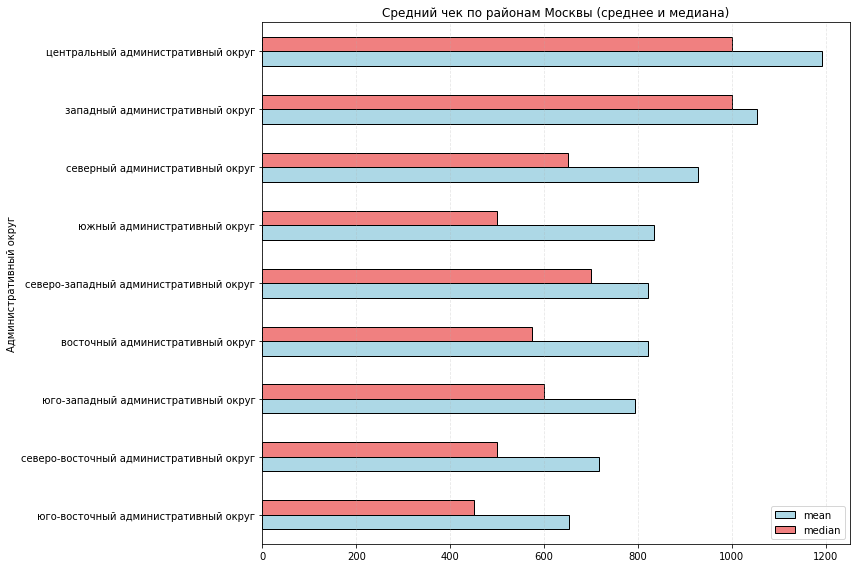

In [58]:
avg_bill_stats = avg_bill_stats.sort_values('mean')
# Строим горизонтальную столбчатую диаграмму
avg_bill_stats[['mean', 'median']].plot(
    kind='barh',
    figsize=(12, 8),
    color=['lightblue', 'lightcoral'],
    edgecolor='black',
    title='Средний чек по районам Москвы (среднее и медиана)',
    ylabel='Средний чек, ₽',
    xlabel='Административный округ'
)

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

---


 Центральный административный округ демонстрирует самый высокий средний чек — 1191 руб., что на 24 % превышает средний чек по остальным округам (958руб.) и почти на 82 % — показатель округа с минимальным чеком (юго‑восточный АО:654,10 руб.). Это отражает типичную для мегаполисов ценообразование за локацию в историческом и деловом центре.     
 
 Наблюдается общая тенденция к уменьшению среднего чека по мере удаления от ЦАО: после ЦАО следуют западный (1053руб.) и северный (927,96 руб.) округа, а наименьшие значения фиксируются в юго‑восточном, северо‑восточном и юго‑западном АО.Такая динамика согласуется с гипотезой о влиянии удалённости от центра на уровень цен.   
 
 Несмотря на общий тренд, связь между удаленностью от центра и ценой не является строго линейной: например, западный округ, который не является ближайшим к центру, занимает второе место по величине чека, что может быть обусловлено высокой долей премиальной застройки, концентрацией бизнес‑центров или развитой досуговой инфраструктурой.    
 
 Данные подтверждают, что близость к центру — один из ключевых аспектов ценообразования в сегменте заведений общепита: заведения в ЦАО ориентированы на более платёжеспособную аудиторию и могут позволить себе более высокие цены за счёт спроса и престижа локации.

---

### Промежуточный вывод


Рынок общественного питания Москвы представляется зрелым и сбалансированным. Доминирующие позиции занимают кафе, рестораны и кофейни, сосредоточенные преимущественно в центре города. Высокие и стабильные рейтинги указывают на то, что качество сервиса вышло на первый план. При этом ценовая политика сильно привязана к локации. Рынок в основном представлен независимыми игроками, однако сегменты быстрого обслуживания и кофеен активно масштабируются через сети.

## Итоговый вывод и рекомендации




В ходе исследования рынка общественного питания Москвы на основе данных за 2022 год был проведен полный цикл анализа: от загрузки и очистки данных до выявления ключевых закономерностей и формулирования рекомендаций для потенциальных инвесторов.

**1. Общие итоги исследования**

Исследование показало, что рынок общественного питания Москвы является зрелым, конкурентным и сегментированным. С помощью анализа категорий, географического распределения, сетевой структуры, ценовых сегментов и рейтингов были выявлены ключевые тренды и "точки роста".

**Основные этапы и полученная информация:**

*   **Предобработка данных:** Была проведена работа по объединению двух датасетов, оптимизации типов данных и устранению дубликатов. Пропуски в данных были проанализированы; большинство из них (в столбцах `hours`,`seats`, `price`, `middle_avg_bill`) были оставлены без изменений, чтобы не искажать реальную картину.
*   **Категории заведений:** Рынок состоит преимущественно из трех основных форматов: **кафе, рестораны и кофейни**, которые суммарно занимают более 69% всех заведений. Это указывает на высокий спрос на форматы, предполагающие длительное пребывание.
*   **Географическое распределение:** Наблюдается сильная концентрация заведений в **Центральном административном округе (27%)**. При этом структура спроса в центре отличается от общей картины по городу: в ЦАО доминируют рестораны (29.9%), в то время как по Москве в целом — кафе.
*   **Сетевые и несетевые заведения:** Рынок преимущественно представлен независимыми игроками (61.9%). Наиболее "сетевыми" категориями являются **булочные (61%)**, **пиццерии (52%)** и **кофейни (51%)**. Это говорит о том, что эти форматы наиболее масштабируемы.
*   **Посадочные места:** Наиболее типичное количество мест для заведения в Москве — **75 (медиана)**. Рестораны, бары и кофейни, как правило, более вместительны.
*   **Рейтинги и корреляции:** Средние рейтинги по категориям находятся в узком диапазоне (4.05–4.38). Наиболее сильную (хотя и умеренную) корреляцию с рейтингом имеет **ценовая категория**. Это указывает на то, что качество обслуживания и уникальность концепции важнее формата.
*   **Топ-15 сетей:** Среди крупнейших сетей доминируют **кофейни и пиццерии**, что подтверждает их высокую масштабируемость. Интересно, что небольшие специализированные сети часто имеют более высокий рейтинг, чем крупные игроки.

**2. Главные выводы**

*   **Характеристика категорий:** Рынок завязан на трех китах — кафе, рестораны и кофейни. Эти форматы наиболее востребованы и, следовательно, характеризуются высокой конкуренцией. Сегменты "быстрое питание", "столовые" и "булочные" занимают меньшую долю, что может указывать на нишевые возможности.
*   **Географические особенности:** Центр Москвы — это "ресторанная". Платёжеспособный спрос и туристический поток делают этот район привлекательным для дорогих и статусных заведений. В остальных округах структура спроса более демократична, с акцентом на кафе и кофейни.
*   **Сеть vs. Независимость:** Доминирование независимых заведений говорит о высоком уровне индивидуального предпринимательства. Для инвестора это означает, что успех проекта сильно зависит от уникальной концепции и маркетинга.
*   **Посадочные места и режим работы:** Для большинства форматов оптимальное количество мест — до 80–100. При этом в сегментах "бар/паб" и "ресторан" встречаются аномально большие залы. Круглосуточная работа не является доминирующим фактором для высокого рейтинга.
*   **Цены и районы:** Наблюдается четкая градация цен: самый высокий средний чек в ЦАО (≈1190 руб.), далее следует западное направление, а самые низкие чеки — на юго-востоке. Удаленность от центра напрямую коррелирует со снижением цен.


**3. Рекомендации для инвесторов**

*   **Выбор категории заведения:**
    *   Рассмотрите форматы **кофейни** или **пиццерии**. Они показывают высокую масштабируемость и стабильный спрос.
    *   Если планируется независимый проект, обратите внимание на ниши с меньшей сетевизацией: **авторские кафе**, **специализированные бары** или **гастрономические проекты**, где можно выделиться уникальным предложением.
    *   Избегайте прямого входа в высококонкурентный сегмент "ресторанов" без сильной уникальной концепции и опыта.

*   **Рекомендованные административные округа:**
    *   **ЦАО** — для премиум-проектов с высокой маржинальностью и готовностью конкурировать за статусного клиента.
    *   **Западный, Северный и Северо-Восточный округа** — для демократичных и "средних" по ценовому сегменту проектов. Эти районы показывают высокий потенциал при меньшей арендной ставке и конкуренции.
    *   **Юго-Восточный округ** — интересен для открытия бюджетных форматов ("кофейня у дома", "столовая"), так как здесь самые низкие цены и, возможно, наименьшее насыщение качественными предложениями.

*   **Оптимальные показатели по вместимости и режиму:**
    *   Оптимальное число посадочных мест для большинства форматов — **50-90**. Крупные залы (более 150 мест) оправданы только для ресторанов с уникальной концепцией или столовых в местах большого скопления людей.
    *   Для кофеен и пиццерий круглосуточный режим работы — опция, позволяющая увеличить выручку, но не критичный фактор успеха. Для баров, напротив, работа допоздна может стать конкурентным преимуществом.

*   **Ориентация на целевую аудиторию и конкурентоспособность:**
    *   Главный вывод: **средний чек > рейтинга**. Инвестируйте в качество ингредиентов и обслуживания. Более дорогие заведения получают более высокие оценки, что оправдывает ценовую политику.
    *   **Уникальность — ваш козырь**. В условиях доминирования сетей ("Шоколадница", "Додо Пицца"), независимый проект может выиграть за счет уникальной атмосферы, авторской кухни или высокого уровня сервиса.
    *   **Помните о географической дифференциации.** Успешная концепция для ЦАО (дорогой ресторан) вряд ли сработает в спальном районе; адаптируйте ассортимент и ценовую политику под локальный спрос и платежеспособность населения.

**Заключение:** Рынок общественного питания Москвы предлагает множество возможностей. Успех принесет не только масштабирование, но и глубокая проработка концепции, понимание локальной географии и фокус на соотношении "цена-качество". Рекомендуется начинать с четкого позиционирования, выбранного на основе анализа конкурентов в конкретном районе, и делать ставку на уникальный продукт и сервис.